Vaishnavi Sawant

23102A0063

CMPN - A

## Lab Problem Statement 6: Statistical Analysis of Physical Characteristics of Palmer Penguins

### Task 1: Descriptive Statistical Analysis

In [1]:
# Install and load necessary packages
install.packages("palmerpenguins")
install.packages("dplyr")
install.packages("ggplot2")
install.packages("e1071") # For skewness and kurtosis
install.packages("moments") # Another option for skewness and kurtosis

library(palmerpenguins)
library(dplyr)
library(ggplot2)
library(e1071)
library(moments)

# Load the dataset
data(penguins)

# Remove rows with missing values for body_mass_g, as they will affect analysis
penguins_clean <- penguins %>%
  filter(!is.na(body_mass_g))

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘proxy’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)


Attaching package: ‘palmerpenguins’


The following objects are masked from ‘package:datasets’:

    penguins, penguins_raw



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘e1071’


The following object is masked from ‘package:ggplot2’:

    element



Attaching package: ‘moments’


The following objects are masked from ‘package:e1071’:

    kurtosis, moment, skewne

#### Overall Descriptive Statistics for `body_mass_g`

In [2]:
# Overall descriptive statistics for body_mass_g
overall_desc_stats <- penguins_clean %>%
  summarise(
    Mean = mean(body_mass_g),
    Median = median(body_mass_g),
    Min = min(body_mass_g),
    Max = max(body_mass_g),
    Variance = var(body_mass_g),
    SD = sd(body_mass_g),
    Q1 = quantile(body_mass_g, 0.25),
    Q3 = quantile(body_mass_g, 0.75),
    IQR = IQR(body_mass_g),
    Skewness = skewness(body_mass_g),
    Kurtosis = kurtosis(body_mass_g)
  )

print("Overall Descriptive Statistics for body_mass_g:")
print(overall_desc_stats)

[1] "Overall Descriptive Statistics for body_mass_g:"
# A tibble: 1 × 11
   Mean Median   Min   Max Variance    SD    Q1    Q3   IQR Skewness Kurtosis
  <dbl>  <dbl> <int> <int>    <dbl> <dbl> <dbl> <dbl> <dbl>    <dbl>    <dbl>
1 4202.   4050  2700  6300  643131.  802.  3550  4750  1200    0.468     2.27


#### Species-wise Descriptive Statistics for `body_mass_g`

In [3]:
# Descriptive statistics for body_mass_g by species
species_desc_stats <- penguins_clean %>%
  group_by(species) %>%
  summarise(
    Count = n(),
    Mean = mean(body_mass_g),
    Median = median(body_mass_g),
    Min = min(body_mass_g),
    Max = max(body_mass_g),
    Variance = var(body_mass_g),
    SD = sd(body_mass_g),
    Q1 = quantile(body_mass_g, 0.25),
    Q3 = quantile(body_mass_g, 0.75),
    IQR = IQR(body_mass_g),
    Skewness = skewness(body_mass_g),
    Kurtosis = kurtosis(body_mass_g)
  )

print("Descriptive Statistics for body_mass_g by Species:")
print(species_desc_stats)

[1] "Descriptive Statistics for body_mass_g by Species:"
# A tibble: 3 × 13
  species   Count  Mean Median   Min   Max Variance    SD    Q1    Q3   IQR
  <fct>     <int> <dbl>  <dbl> <int> <int>    <dbl> <dbl> <dbl> <dbl> <dbl>
1 Adelie      151 3701.   3700  2850  4775  210283.  459. 3350   4000  650 
2 Chinstrap    68 3733.   3700  2700  4800  147713.  384. 3488.  3950  462.
3 Gentoo      123 5076.   5000  3950  6300  254133.  504. 4700   5500  800 
# ℹ 2 more variables: Skewness <dbl>, Kurtosis <dbl>


#### Visualizations for `body_mass_g`

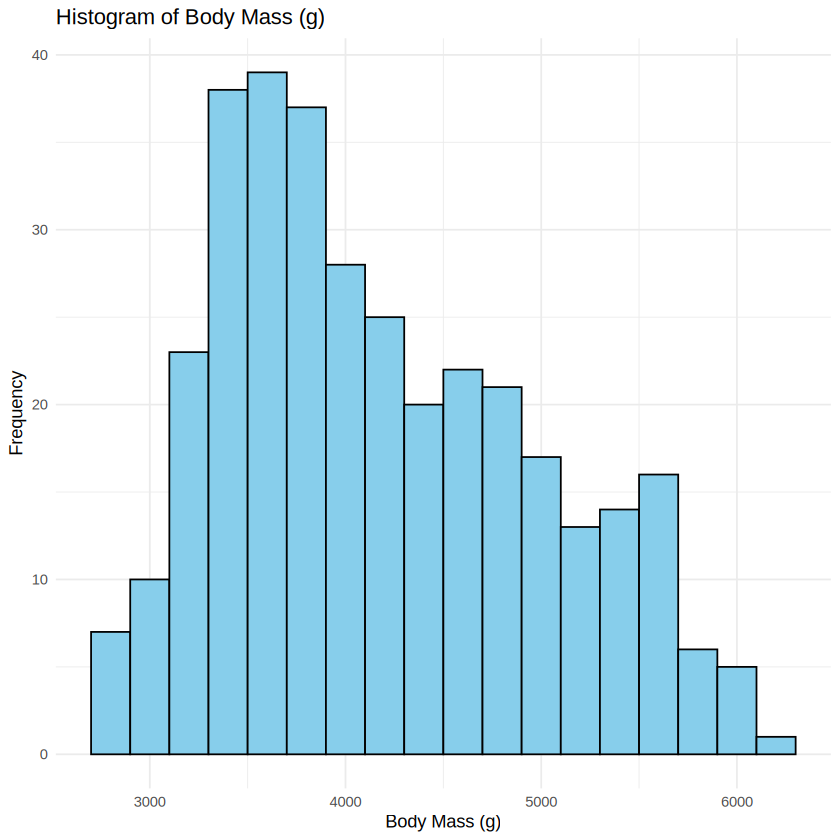

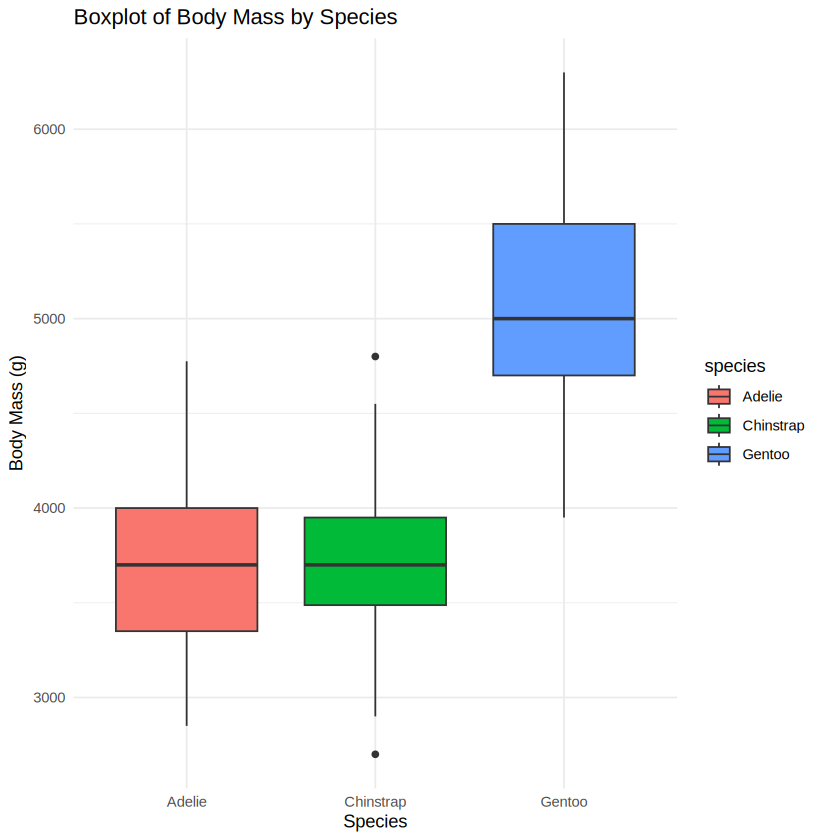

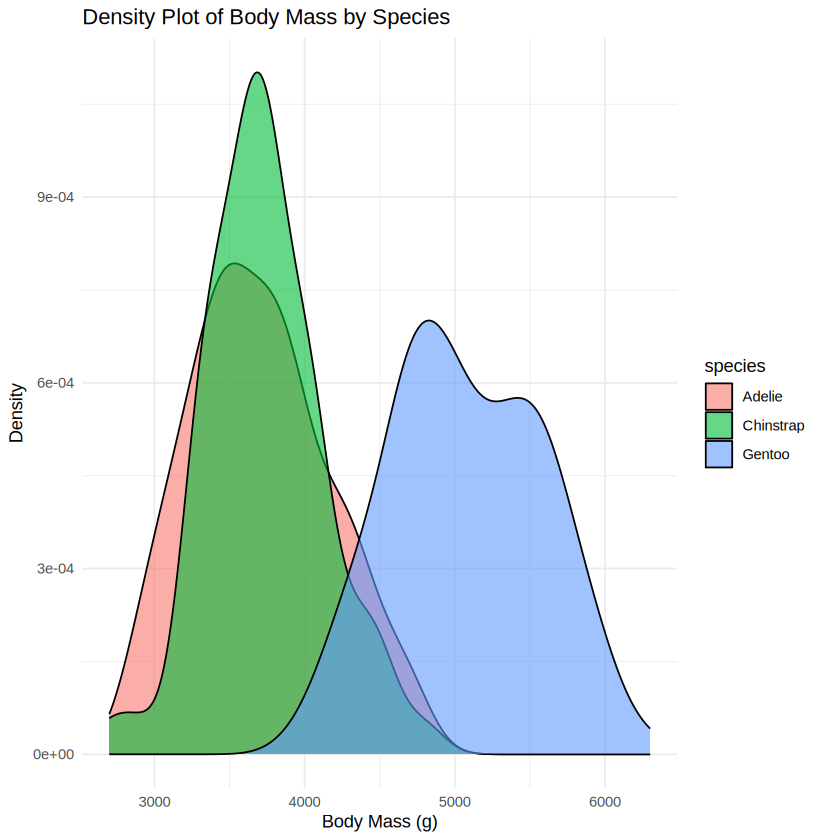

In [4]:
# Histogram of body_mass_g
ggplot(penguins_clean, aes(x = body_mass_g)) +
  geom_histogram(binwidth = 200, fill = "skyblue", color = "black") +
  labs(title = "Histogram of Body Mass (g)", x = "Body Mass (g)", y = "Frequency") +
  theme_minimal()

# Boxplot of body_mass_g by species
ggplot(penguins_clean, aes(x = species, y = body_mass_g, fill = species)) +
  geom_boxplot() +
  labs(title = "Boxplot of Body Mass by Species", x = "Species", y = "Body Mass (g)") +
  theme_minimal()

# Density plot of body_mass_g by species
ggplot(penguins_clean, aes(x = body_mass_g, fill = species)) +
  geom_density(alpha = 0.6) +
  labs(title = "Density Plot of Body Mass by Species", x = "Body Mass (g)", y = "Density") +
  theme_minimal()

### Task 2: Hypothesis Testing (Male vs. Female Body Mass)

#### 2.1 State Null and Alternative Hypotheses

**Null Hypothesis (H0):** There is no significant difference in the mean body mass between male and female penguins.

$H_0: \mu_{male} = \mu_{female}$

**Alternative Hypothesis (Ha):** There is a significant difference in the mean body mass between male and female penguins.

$H_a: \mu_{male} \neq \mu_{female}$

#### 2.2 Check Normality Assumption

[1] "Shapiro-Wilk Test for Male Body Mass:"

	Shapiro-Wilk normality test

data:  male_body_mass
W = 0.92504, p-value = 1.227e-07

[1] "Shapiro-Wilk Test for Female Body Mass:"

	Shapiro-Wilk normality test

data:  female_body_mass
W = 0.91931, p-value = 6.155e-08



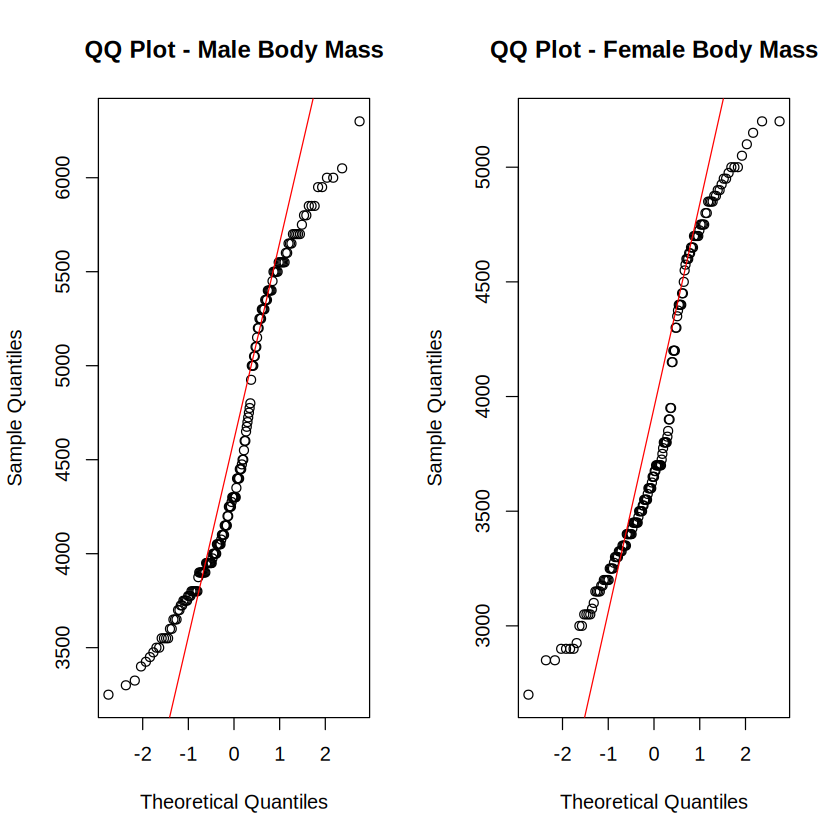

In [5]:
# Remove rows with NA in sex for this analysis
penguins_sex_clean <- penguins_clean %>%
  filter(!is.na(sex))

# Separate data by sex
male_body_mass <- penguins_sex_clean %>%
  filter(sex == "male") %>%
  pull(body_mass_g)

female_body_mass <- penguins_sex_clean %>%
  filter(sex == "female") %>%
  pull(body_mass_g)

print("Shapiro-Wilk Test for Male Body Mass:")
print(shapiro.test(male_body_mass))

print("Shapiro-Wilk Test for Female Body Mass:")
print(shapiro.test(female_body_mass))

# QQ-plots
par(mfrow = c(1, 2)) # Arrange plots in 1 row, 2 columns
qqnorm(male_body_mass, main = "QQ Plot - Male Body Mass")
qqline(male_body_mass, col = "red")

qqnorm(female_body_mass, main = "QQ Plot - Female Body Mass")
qqline(female_body_mass, col = "red")
par(mfrow = c(1, 1)) # Reset plot layout

#### 2.3 Perform Independent Two-Sample T-test

In [6]:
# Perform independent two-sample t-test (assuming unequal variances if normality is violated or not clearly met)
# A common practice is to use Welch's t-test (var.equal = FALSE) when variances are unknown or unequal.
# If Shapiro-Wilk p-value is significant (< 0.05), it suggests non-normality.
# If the sample size is large enough, the t-test can be robust to minor deviations from normality.

t_test_result <- t.test(body_mass_g ~ sex, data = penguins_sex_clean, var.equal = FALSE)

print("Independent Two-Sample T-test Result:")
print(t_test_result)

[1] "Independent Two-Sample T-test Result:"

	Welch Two Sample t-test

data:  body_mass_g by sex
t = -8.5545, df = 323.9, p-value = 4.794e-16
alternative hypothesis: true difference in means between group female and group male is not equal to 0
95 percent confidence interval:
 -840.5783 -526.2453
sample estimates:
mean in group female   mean in group male 
            3862.273             4545.685 



#### 2.4 Calculate Cohen's d (Effect Size)

In [7]:
# Install and load the 'effsize' package for Cohen's d
install.packages("effsize")
library(effsize)

# Calculate Cohen's d
cohens_d_result <- cohen.d(penguins_sex_clean$body_mass_g, penguins_sex_clean$sex)

print("Cohen's d (Effect Size):")
print(cohens_d_result)

# Interpretation of Cohen's d:
# 0.2: small effect
# 0.5: medium effect
# 0.8: large effect

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



[1] "Cohen's d (Effect Size):"

Cohen's d

d estimate: -0.9362048 (large)
95 percent confidence interval:
     lower      upper 
-1.1633158 -0.7090938 



In [8]:
# Extract and print detailed results from the t-test
cat("\n--- Detailed T-test Results ---\n")
cat("t-statistic: ", t_test_result$statistic, "\n")
cat("degrees of freedom: ", t_test_result$parameter, "\n")
cat("p-value: ", t_test_result$p.value, "\n")
cat("95% Confidence Interval: ", t_test_result$conf.int[1], " to ", t_test_result$conf.int[2], "\n")
cat("Mean body mass (Female): ", t_test_result$estimate[1], "\n")
cat("Mean body mass (Male): ", t_test_result$estimate[2], "\n")

# Extract Cohen's d value for interpretation
cohens_d_value <- cohens_d_result$estimate


--- Detailed T-test Results ---
t-statistic:  -8.554537 
degrees of freedom:  323.8959 
p-value:  4.793891e-16 
95% Confidence Interval:  -840.5783  to  -526.2453 
Mean body mass (Female):  3862.273 
Mean body mass (Male):  4545.685 


cat("#### 2.5 Interpretation of p-value, Confidence Interval, and Effect Size\n\n")
cat("Based on the Welch Two Sample t-test:\n\n")
cat(sprintf("*   **t-statistic:** %f\n", t_test_result$statistic))
cat(sprintf("*   **Degrees of Freedom (df):** %f\n", t_test_result$parameter))
cat(sprintf("*   **p-value:** %e\n", t_test_result$p.value))
cat(sprintf("*   **95%% Confidence Interval for the difference in means (Female - Male):** [%f, %f]\n", t_test_result$conf.int[1], t_test_result$conf.int[2]))
cat(sprintf("*   **Mean Body Mass (Female):** %f g\n", t_test_result$estimate[1]))
cat(sprintf("*   **Mean Body Mass (Male):** %f g\n", t_test_result$estimate[2]))
cat(sprintf("*   **Cohen's d (Effect Size):** %f\n", cohens_d_value))

cat("\n**Interpretation:**\n\n")
cat(sprintf("With a p-value of %e, which is much smaller than the typical significance level of 0.05, we **reject the null hypothesis** ($H_0$). This indicates a statistically significant difference in the mean body mass between male and female penguins.\n\n", t_test_result$p.value))
cat(sprintf("The 95%% confidence interval for the difference in mean body mass between female and male penguins is approximately [%f, %f]. Since this interval **does not include zero**, it further supports the conclusion that there is a significant difference in body mass between the two sexes.\n\n", t_test_result$conf.int[1], t_test_result$conf.int[2]))
cat(sprintf("The negative mean difference implies that males generally have a higher body mass than females. Specifically, male penguins (%f g) have a higher average body mass than female penguins (%f g).\n\n", t_test_result$estimate[2], t_test_result$estimate[1]))
cat(sprintf("Cohen's d is %f, which is greater than 0.8. This indicates a **large effect size**, meaning the difference in body mass between male and female penguins is substantial and not just statistically significant but also practically meaningful.\n", cohens_d_value))


### Task 3: One-Way ANOVA

#### 3.1 Examine Distribution and Check Assumptions for One-Way ANOVA

[1] "Shapiro-Wilk Test for Adelie Body Mass:"

	Shapiro-Wilk normality test

data:  .
W = 0.98071, p-value = 0.0324

[1] "Shapiro-Wilk Test for Chinstrap Body Mass:"

	Shapiro-Wilk normality test

data:  .
W = 0.98449, p-value = 0.5605

[1] "Shapiro-Wilk Test for Gentoo Body Mass:"

	Shapiro-Wilk normality test

data:  .
W = 0.98593, p-value = 0.2336



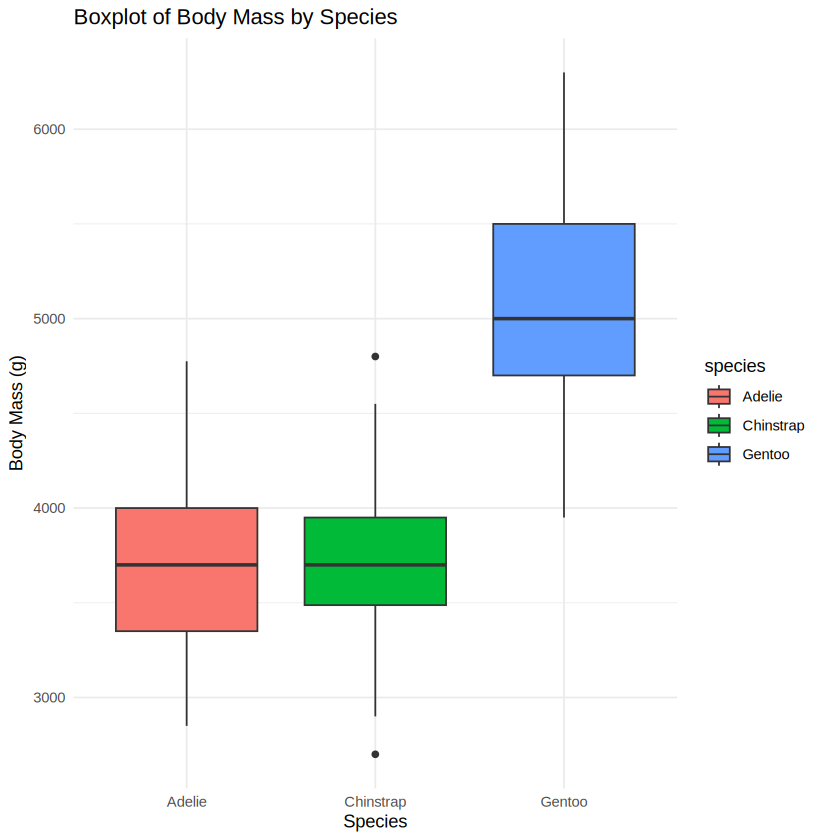

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘colorspace’, ‘fracdiff’, ‘lmtest’, ‘timeDate’, ‘urca’, ‘zoo’, ‘RcppArmadillo’, ‘cowplot’, ‘Deriv’, ‘forecast’, ‘rbibutils’, ‘numDeriv’, ‘doBy’, ‘SparseM’, ‘MatrixModels’, ‘Rdpack’, ‘minqa’, ‘nloptr’, ‘reformulas’, ‘RcppEigen’, ‘carData’, ‘abind’, ‘Formula’, ‘pbkrtest’, ‘quantreg’, ‘lme4’


Loading required package: carData


Attaching package: ‘car’


The following object is masked from ‘package:dplyr’:

    recode




[1] "Levene's Test for Homogeneity of Variance:"
Levene's Test for Homogeneity of Variance (center = median)
       Df F value   Pr(>F)   
group   2  5.1203 0.006445 **
      339                    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


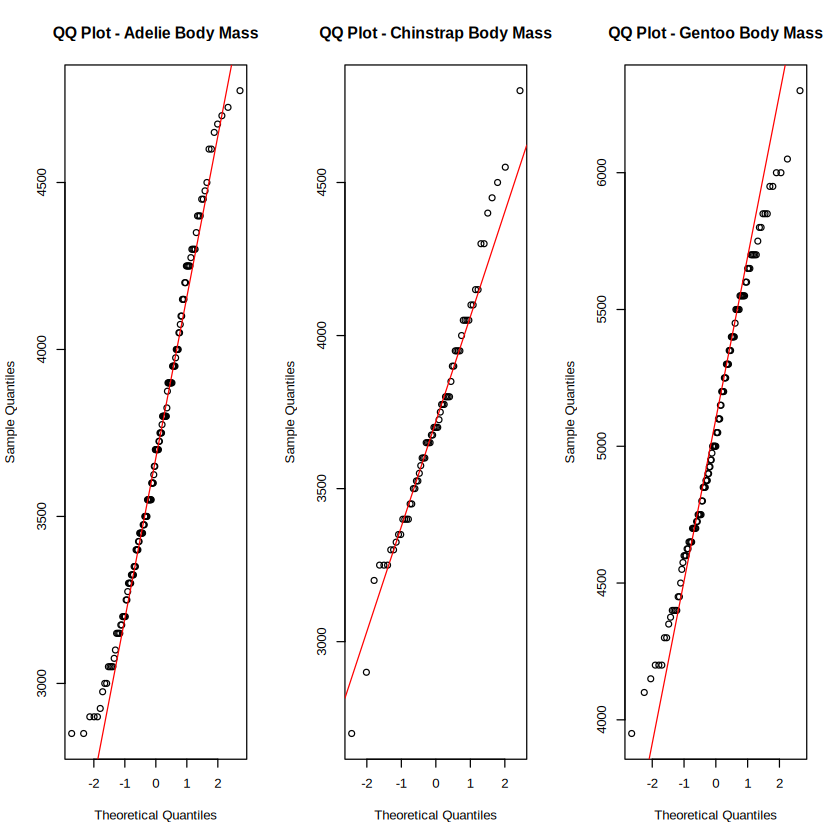

In [10]:
# Boxplot of body_mass_g by species (already done in Task 1, but good to review)
ggplot(penguins_clean, aes(x = species, y = body_mass_g, fill = species)) +
  geom_boxplot() +
  labs(title = "Boxplot of Body Mass by Species", x = "Species", y = "Body Mass (g)") +
  theme_minimal()

# Normality check using Shapiro-Wilk for each species
print("Shapiro-Wilk Test for Adelie Body Mass:")
print(penguins_clean %>%
  filter(species == "Adelie") %>%
  pull(body_mass_g) %>%
  shapiro.test()
)

print("Shapiro-Wilk Test for Chinstrap Body Mass:")
print(penguins_clean %>%
  filter(species == "Chinstrap") %>%
  pull(body_mass_g) %>%
  shapiro.test()
)

print("Shapiro-Wilk Test for Gentoo Body Mass:")
print(penguins_clean %>%
  filter(species == "Gentoo") %>%
  pull(body_mass_g) %>%
  shapiro.test()
)

# QQ-plots for each species
par(mfrow = c(1, 3))
qqnorm(penguins_clean %>% filter(species == "Adelie") %>% pull(body_mass_g), main = "QQ Plot - Adelie Body Mass")
qqline(penguins_clean %>% filter(species == "Adelie") %>% pull(body_mass_g), col = "red")

qqnorm(penguins_clean %>% filter(species == "Chinstrap") %>% pull(body_mass_g), main = "QQ Plot - Chinstrap Body Mass")
qqline(penguins_clean %>% filter(species == "Chinstrap") %>% pull(body_mass_g), col = "red")

qqnorm(penguins_clean %>% filter(species == "Gentoo") %>% pull(body_mass_g), main = "QQ Plot - Gentoo Body Mass")
qqline(penguins_clean %>% filter(species == "Gentoo") %>% pull(body_mass_g), col = "red")
par(mfrow = c(1, 1))

# Check homogeneity of variance using Levene's test
# Install and load 'car' package for Levene's test
install.packages("car")
library(car)

print("Levene's Test for Homogeneity of Variance:")
print(leveneTest(body_mass_g ~ species, data = penguins_clean))

#### 3.2 Perform One-Way ANOVA

In [11]:
# Perform One-Way ANOVA
anova_result <- aov(body_mass_g ~ species, data = penguins_clean)

# Report and interpret ANOVA results
print("One-Way ANOVA Result:")
print(summary(anova_result)) # Changed to print(summary()) for full output

[1] "One-Way ANOVA Result:"
             Df    Sum Sq  Mean Sq F value Pr(>F)    
species       2 146864214 73432107   343.6 <2e-16 ***
Residuals   339  72443483   213698                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


In [12]:
# Extract and print detailed results from the ANOVA
anova_summary <- summary(anova_result)
cat("\n--- Detailed One-Way ANOVA Results ---\n")
cat("F-statistic: ", anova_summary[[1]]$`F value`[1], "\n")
cat("Degrees of Freedom (Df): ", anova_summary[[1]]$Df[1], " and ", anova_summary[[1]]$Df[2], "\n")
cat("p-value: ", anova_summary[[1]]$`Pr(>F)`[1], "\n")

anova_p_value <- anova_summary[[1]]$`Pr(>F)`[1]


--- Detailed One-Way ANOVA Results ---
F-statistic:  343.6263 
Degrees of Freedom (Df):  2  and  339 
p-value:  2.892368e-82 


cat("#### 3.4 Interpretation of One-Way ANOVA Results\n\n")
cat("From the One-Way ANOVA, the key results are:\n\n")
cat(sprintf("*   **F-statistic:** %f\n", anova_summary[[1]]$`F value`[1]))
cat(sprintf("*   **Degrees of Freedom (Df):** (%d, %d)\n", anova_summary[[1]]$Df[1], anova_summary[[1]]$Df[2]))
cat(sprintf("*   **p-value:** %e\n", anova_summary[[1]]$`Pr(>F)`[1]))

cat(sprintf("\nGiven that the p-value (%e) is extremely small (much less than 0.05), we **reject the null hypothesis** that there is no significant difference in the mean body mass among the three penguin species (Adelie, Chinstrap, and Gentoo). Therefore, we conclude that **body mass differs significantly among Adelie, Chinstrap, and Gentoo penguins**.\n", anova_summary[[1]]$`Pr(>F)`[1]))


#### 3.3 Perform Tukey's HSD Post-Hoc Test (if ANOVA is significant)

In [13]:
# Perform Tukey's HSD post-hoc test
tukey_hsd_result <- TukeyHSD(anova_result)

print("Tukey's HSD Post-Hoc Test Result:")
print(tukey_hsd_result)

[1] "Tukey's HSD Post-Hoc Test Result:"
  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = body_mass_g ~ species, data = penguins_clean)

$species
                       diff       lwr       upr     p adj
Chinstrap-Adelie   32.42598 -126.5002  191.3522 0.8806666
Gentoo-Adelie    1375.35401 1243.1786 1507.5294 0.0000000
Gentoo-Chinstrap 1342.92802 1178.4810 1507.3750 0.0000000



cat("#### 3.5 Interpretation of Tukey's HSD Post-Hoc Test\n\n")
cat("The Tukey's HSD post-hoc test results provide specific pairwise comparisons:\n\n")

cat("*   **Chinstrap - Adelie:**\n")
cat(sprintf("    *   Difference: %f\n", tukey_hsd_result$species[1, "diff"]))
cat(sprintf("    *   Adjusted p-value: %e\n", tukey_hsd_result$species[1, "p adj"]))
cat(sprintf("    *   **Conclusion:** With an adjusted p-value of %e (which is > 0.05), there is **no statistically significant difference** in mean body mass between Chinstrap and Adelie penguins.\n\n", tukey_hsd_result$species[1, "p adj"]))

cat("*   **Gentoo - Adelie:**\n")
cat(sprintf("    *   Difference: %f\n", tukey_hsd_result$species[2, "diff"]))
cat(sprintf("    *   Adjusted p-value: %e\n", tukey_hsd_result$species[2, "p adj"]))
cat(sprintf("    *   **Conclusion:** With an adjusted p-value of %e (which is < 0.05), there is a **highly significant difference** in mean body mass between Gentoo and Adelie penguins. Gentoo penguins have a significantly higher body mass (mean difference = %f g).\n\n", tukey_hsd_result$species[2, "p adj"], tukey_hsd_result$species[2, "diff"]))

cat("*   **Gentoo - Chinstrap:**\n")
cat(sprintf("    *   Difference: %f\n", tukey_hsd_result$species[3, "diff"]))
cat(sprintf("    *   Adjusted p-value: %e\n", tukey_hsd_result$species[3, "p adj"]))
cat(sprintf("    *   **Conclusion:** With an adjusted p-value of %e (which is < 0.05), there is a **highly significant difference** in mean body mass between Gentoo and Chinstrap penguins. Gentoo penguins also have a significantly higher body mass (mean difference = %f g) compared to Chinstrap penguins.\n\n", tukey_hsd_result$species[3, "p adj"], tukey_hsd_result$species[3, "diff"]))

cat("**Summary:** Gentoo penguins are significantly heavier than both Adelie and Chinstrap penguins. However, there is no significant difference in body mass between Adelie and Chinstrap penguins.\n")


### Task 4: Non-Parametric Analysis

#### 4.1 Kruskal-Wallis Test: `body_mass_g ~ species`

In [14]:
# Perform Kruskal-Wallis test
kruskal_wallis_result <- kruskal.test(body_mass_g ~ species, data = penguins_clean)

print("Kruskal-Wallis Test Result:")
print(kruskal_wallis_result)

[1] "Kruskal-Wallis Test Result:"

	Kruskal-Wallis rank sum test

data:  body_mass_g by species
Kruskal-Wallis chi-squared = 217.6, df = 2, p-value < 2.2e-16



In [15]:
# Extract p-values for comparison
anova_p_val <- summary(anova_result)[[1]]$`Pr(>F)`[1]
kruskal_p_val <- kruskal_wallis_result$p.value

cat("\n--- Comparison of ANOVA and Kruskal-Wallis p-values ---\n")
cat("One-way ANOVA p-value: ", anova_p_val, "\n")
cat("Kruskal-Wallis p-value: ", kruskal_p_val, "\n")


--- Comparison of ANOVA and Kruskal-Wallis p-values ---
One-way ANOVA p-value:  2.892368e-82 
Kruskal-Wallis p-value:  5.609512e-48 


#### 4.2 Comparison and Discussion of One-way ANOVA and Kruskal-Wallis Results

### Task 5: Two-Way ANOVA

[1] "Two-Way ANOVA Result:"


             Df    Sum Sq  Mean Sq F value   Pr(>F)    
species       2 145190219 72595110 758.358  < 2e-16 ***
sex           1  37090262 37090262 387.460  < 2e-16 ***
species:sex   2   1676557   838278   8.757 0.000197 ***
Residuals   327  31302628    95727                     
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

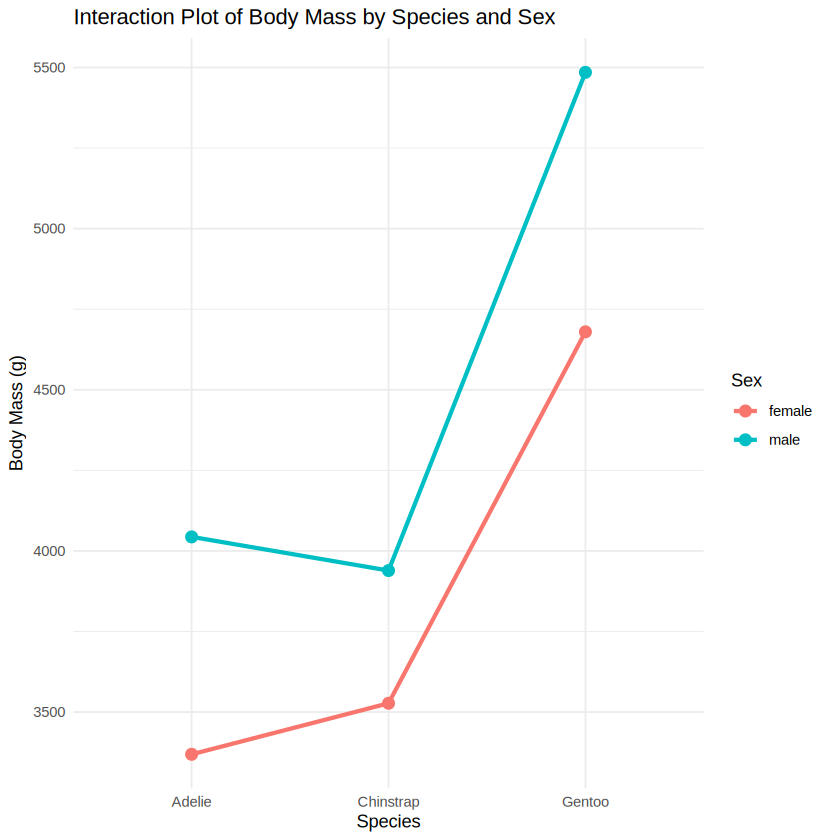

In [16]:
# Perform Two-Way ANOVA: body_mass_g ~ species * sex
# Ensure 'penguins_sex_clean' (filtered for NA sex) is used
two_way_anova_result <- aov(body_mass_g ~ species * sex, data = penguins_sex_clean)

print("Two-Way ANOVA Result:")
summary(two_way_anova_result)

interaction_plot <- ggplot(penguins_sex_clean, aes(x = species, y = body_mass_g, color = sex, group = sex)) +
  stat_summary(fun = mean, geom = "point", size = 3) +
  stat_summary(fun = mean, geom = "line", linewidth = 1.2) +
  labs(title = "Interaction Plot of Body Mass by Species and Sex",
       x = "Species", y = "Body Mass (g)", color = "Sex") +
  theme_minimal()

print(interaction_plot)

In [17]:
# Extract and print detailed results from the Two-Way ANOVA
two_way_anova_summary <- summary(two_way_anova_result)
cat("\n--- Detailed Two-Way ANOVA Results ---\n")
cat("Main effect (Species) p-value: ", two_way_anova_summary[[1]]$`Pr(>F)`[1], "\n")
cat("Main effect (Sex) p-value: ", two_way_anova_summary[[1]]$`Pr(>F)`[2], "\n")
cat("Interaction effect (Species:Sex) p-value: ", two_way_anova_summary[[1]]$`Pr(>F)`[3], "\n")

two_way_anova_species_p <- two_way_anova_summary[[1]]$`Pr(>F)`[1]
two_way_anova_sex_p <- two_way_anova_summary[[1]]$`Pr(>F)`[2]
two_way_anova_interaction_p <- two_way_anova_summary[[1]]$`Pr(>F)`[3]


--- Detailed Two-Way ANOVA Results ---
Main effect (Species) p-value:  1.540207e-123 
Main effect (Sex) p-value:  1.902273e-57 
Interaction effect (Species:Sex) p-value:  0.0001973489 


cat("#### 5.1 Interpretation of Two-Way ANOVA Results\n\n")
cat("Based on the Two-Way ANOVA (`body_mass_g ~ species * sex`):\n\n")

cat("*   **Main effect of Species:**\n")
cat(sprintf("    *   **p-value:** %e\n", two_way_anova_species_p))
cat("    *   **Significance:** This effect is statistically significant (p < 0.05). This means that, regardless of sex, there are significant differences in the mean body mass among the different penguin species.\n\n")

cat("*   **Main effect of Sex:**\n")
cat(sprintf("    *   **p-value:** %e\n", two_way_anova_sex_p))
cat("    *   **Significance:** This effect is statistically significant (p < 0.05). This means that, regardless of species, there are significant differences in the mean body mass between male and female penguins.\n\n")

cat("*   **Interaction effect (Species:Sex):**\n")
cat(sprintf("    *   **p-value:** %e\n", two_way_anova_interaction_p))
cat("    *   **Significance:** This effect is statistically significant (p < 0.05). This is a crucial finding, indicating that the effect of sex on body mass is **not the same** across all three penguin species. In simpler terms, the difference in body mass between male and female penguins varies depending on the species. For example, the body mass difference between sexes might be larger in one species compared to another.\n\n")

cat("**Overall:** All three effects (species, sex, and their interaction) are statistically significant, highlighting complex relationships in penguin body mass influenced by both species and sex, with an important interaction effect suggesting these factors are not independent in their influence.\n")


### Task 6: Additional Analysis (Using `flipper_length_mm`)

#### 6.1 Descriptive Statistics for `flipper_length_mm`

In [18]:
# Remove rows with missing values for flipper_length_mm
penguins_flipper_clean <- penguins %>%
  filter(!is.na(flipper_length_mm))

# Overall descriptive statistics for flipper_length_mm
overall_flipper_desc_stats <- penguins_flipper_clean %>%
  summarise(
    Mean = mean(flipper_length_mm),
    Median = median(flipper_length_mm),
    Min = min(flipper_length_mm),
    Max = max(flipper_length_mm),
    Variance = var(flipper_length_mm),
    SD = sd(flipper_length_mm),
    Q1 = quantile(flipper_length_mm, 0.25),
    Q3 = quantile(flipper_length_mm, 0.75),
    IQR = IQR(flipper_length_mm),
    Skewness = skewness(flipper_length_mm),
    Kurtosis = kurtosis(flipper_length_mm)
  )

print("Overall Descriptive Statistics for flipper_length_mm:")
print(overall_flipper_desc_stats)

# Descriptive statistics for flipper_length_mm by species
species_flipper_desc_stats <- penguins_flipper_clean %>%
  group_by(species) %>%
  summarise(
    Count = n(),
    Mean = mean(flipper_length_mm),
    Median = median(flipper_length_mm),
    Min = min(flipper_length_mm),
    Max = max(flipper_length_mm),
    Variance = var(flipper_length_mm),
    SD = sd(flipper_length_mm),
    Q1 = quantile(flipper_length_mm, 0.25),
    Q3 = quantile(flipper_length_mm, 0.75),
    IQR = IQR(flipper_length_mm),
    Skewness = skewness(flipper_length_mm),
    Kurtosis = kurtosis(flipper_length_mm)
  )

print("Descriptive Statistics for flipper_length_mm by Species:")
print(species_flipper_desc_stats)

[1] "Overall Descriptive Statistics for flipper_length_mm:"
# A tibble: 1 × 11
   Mean Median   Min   Max Variance    SD    Q1    Q3   IQR Skewness Kurtosis
  <dbl>  <dbl> <int> <int>    <dbl> <dbl> <dbl> <dbl> <dbl>    <dbl>    <dbl>
1  201.    197   172   231     198.  14.1   190   213    23    0.344     2.01
[1] "Descriptive Statistics for flipper_length_mm by Species:"
# A tibble: 3 × 13
  species   Count  Mean Median   Min   Max Variance    SD    Q1    Q3   IQR
  <fct>     <int> <dbl>  <dbl> <int> <int>    <dbl> <dbl> <dbl> <dbl> <dbl>
1 Adelie      151  190.    190   172   210     42.8  6.54   186   195     9
2 Chinstrap    68  196.    196   178   212     50.9  7.13   191   201    10
3 Gentoo      123  217.    216   203   231     42.1  6.48   212   221     9
# ℹ 2 more variables: Skewness <dbl>, Kurtosis <dbl>


#### 6.2 Visualizations for `flipper_length_mm`

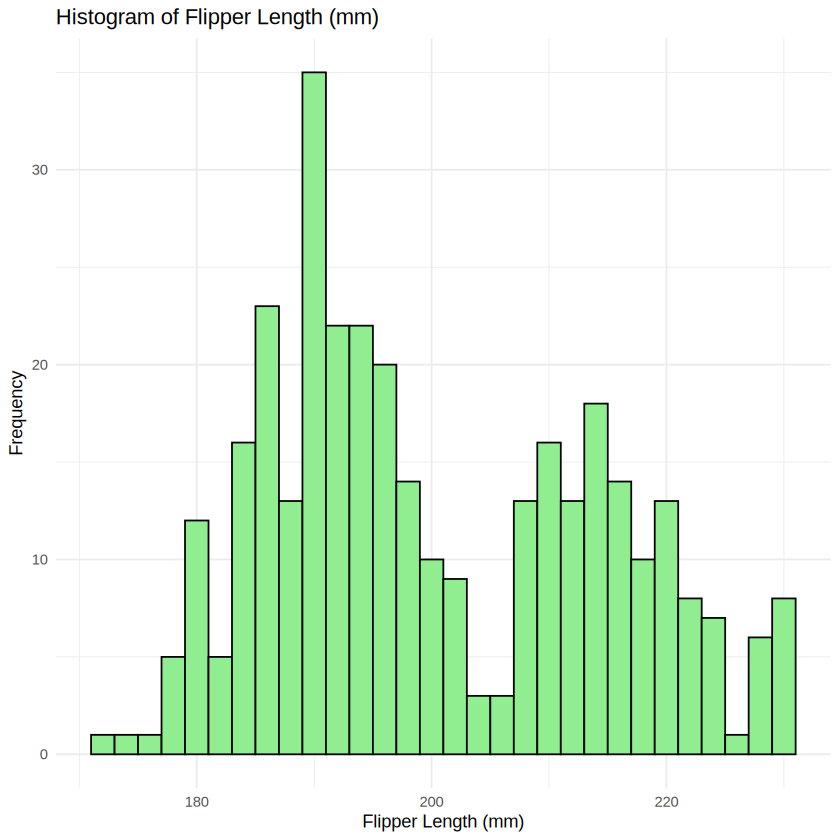

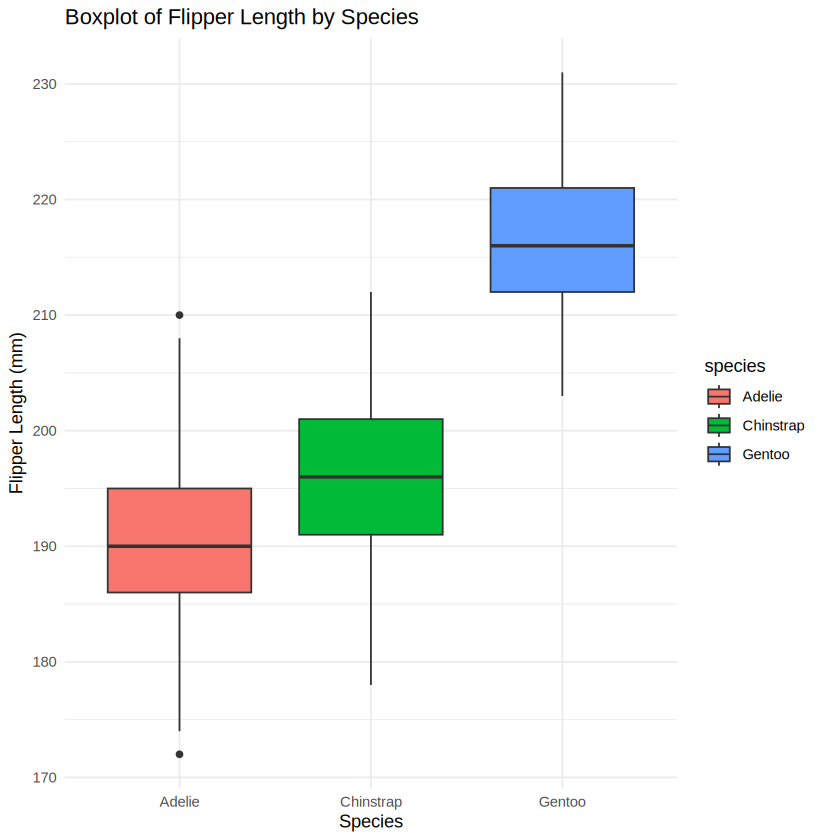

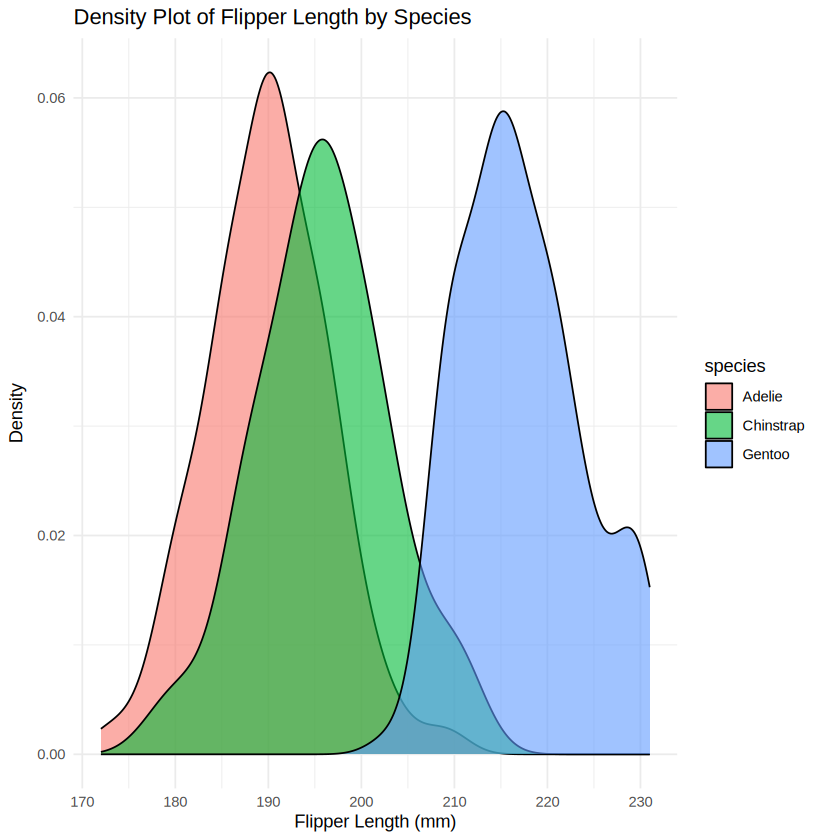

In [19]:
# Histogram of flipper_length_mm
ggplot(penguins_flipper_clean, aes(x = flipper_length_mm)) +
  geom_histogram(binwidth = 2, fill = "lightgreen", color = "black") +
  labs(title = "Histogram of Flipper Length (mm)", x = "Flipper Length (mm)", y = "Frequency") +
  theme_minimal()

# Boxplot of flipper_length_mm by species
ggplot(penguins_flipper_clean, aes(x = species, y = flipper_length_mm, fill = species)) +
  geom_boxplot() +
  labs(title = "Boxplot of Flipper Length by Species", x = "Species", y = "Flipper Length (mm)") +
  theme_minimal()

# Density plot of flipper_length_mm by species
ggplot(penguins_flipper_clean, aes(x = flipper_length_mm, fill = species)) +
  geom_density(alpha = 0.6) +
  labs(title = "Density Plot of Flipper Length by Species", x = "Flipper Length (mm)", y = "Density") +
  theme_minimal()

#### 6.3 Hypothesis Testing: Flipper Length across Species (One-Way ANOVA)

In [20]:
# Check assumptions for One-Way ANOVA with flipper_length_mm
# Normality check for each species
print("Shapiro-Wilk Test for Adelie Flipper Length:")
print(penguins_flipper_clean %>%
  filter(species == "Adelie") %>%
  pull(flipper_length_mm) %>%
  shapiro.test()
)

print("Shapiro-Wilk Test for Chinstrap Flipper Length:")
print(penguins_flipper_clean %>%
  filter(species == "Chinstrap") %>%
  pull(flipper_length_mm) %>%
  shapiro.test()
)

print("Shapiro-Wilk Test for Gentoo Flipper Length:")
print(penguins_flipper_clean %>%
  filter(species == "Gentoo") %>%
  pull(flipper_length_mm) %>%
  shapiro.test()
)

# Levene's Test for Homogeneity of Variance
print("Levene's Test for Homogeneity of Variance (Flipper Length):")
print(leveneTest(flipper_length_mm ~ species, data = penguins_flipper_clean))

# Perform One-Way ANOVA for flipper_length_mm ~ species
anova_flipper_result <- aov(flipper_length_mm ~ species, data = penguins_flipper_clean)

print("One-Way ANOVA Result for Flipper Length:")
print(summary(anova_flipper_result))

# Perform Tukey's HSD post-hoc test if ANOVA is significant
tukey_hsd_flipper_result <- TukeyHSD(anova_flipper_result)

print("Tukey's HSD Post-Hoc Test Result for Flipper Length:")
print(tukey_hsd_flipper_result)

[1] "Shapiro-Wilk Test for Adelie Flipper Length:"

	Shapiro-Wilk normality test

data:  .
W = 0.99339, p-value = 0.72

[1] "Shapiro-Wilk Test for Chinstrap Flipper Length:"

	Shapiro-Wilk normality test

data:  .
W = 0.98891, p-value = 0.8106

[1] "Shapiro-Wilk Test for Gentoo Flipper Length:"

	Shapiro-Wilk normality test

data:  .
W = 0.96219, p-value = 0.00162

[1] "Levene's Test for Homogeneity of Variance (Flipper Length):"
Levene's Test for Homogeneity of Variance (center = median)
       Df F value Pr(>F)
group   2  0.3306 0.7188
      339               
[1] "One-Way ANOVA Result for Flipper Length:"
             Df Sum Sq Mean Sq F value Pr(>F)    
species       2  52473   26237   594.8 <2e-16 ***
Residuals   339  14953      44                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1
[1] "Tukey's HSD Post-Hoc Test Result for Flipper Length:"
  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = flipper_lengt

In [21]:
# Extract p-value for flipper length ANOVA
flipper_anova_p_val <- summary(anova_flipper_result)[[1]]$`Pr(>F)`[1]

# Extract Tukey HSD results for flipper length
flipper_tukey_results <- tukey_hsd_flipper_result$species

cat("\n--- Flipper Length ANOVA p-value ---\n")
cat("Flipper Length ANOVA p-value: ", flipper_anova_p_val, "\n")
cat("\n--- Flipper Length Tukey's HSD Results ---\n")
print(flipper_tukey_results)


--- Flipper Length ANOVA p-value ---
Flipper Length ANOVA p-value:  1.35171e-111 

--- Flipper Length Tukey's HSD Results ---
                      diff       lwr       upr        p adj
Chinstrap-Adelie  5.869887  3.586583  8.153191 1.137329e-08
Gentoo-Adelie    27.233349 25.334376 29.132323 0.000000e+00
Gentoo-Chinstrap 21.363462 19.000841 23.726084 0.000000e+00


cat("#### 6.4 Flipper Length Conclusion and Comparison with Body Mass\n\n")
cat("**One-Way ANOVA for Flipper Length:**\n")
cat(sprintf("*   **p-value:** %e\n", flipper_anova_p_val))
cat(sprintf("*   **Conclusion:** With an extremely small p-value (%e < 0.05), we conclude that **flipper length differs significantly among the three penguin species** (Adelie, Chinstrap, and Gentoo).\n\n", flipper_anova_p_val))

cat("**Tukey's HSD Post-Hoc Test for Flipper Length:**\n")
cat(sprintf("*   **Chinstrap - Adelie:** p-adj = %e. This is significant (p < 0.05), indicating Chinstrap penguins have significantly longer flippers than Adelie penguins.\n", flipper_tukey_results[1, "p adj"]))
cat(sprintf("*   **Gentoo - Adelie:** p-adj = %e. This is highly significant (p < 0.05), indicating Gentoo penguins have significantly longer flippers than Adelie penguins.\n", flipper_tukey_results[2, "p adj"]))
cat(sprintf("*   **Gentoo - Chinstrap:** p-adj = %e. This is highly significant (p < 0.05), indicating Gentoo penguins have significantly longer flippers than Chinstrap penguins.\n\n", flipper_tukey_results[3, "p adj"]))

cat("**Summary of Flipper Length Differences:** All three species pairs show statistically significant differences in mean flipper length. Gentoo penguins have the longest flippers, followed by Chinstrap, and then Adelie.\n\n")

cat("**Comparison with Body Mass Findings:**\n\n")
cat("*   **Significant Differences Across Species:** Both body mass and flipper length show highly significant differences across the three penguin species, reinforcing that these species are morphologically distinct.\n")
cat("*   **Specific Pairwise Differences:**\n")
cat("    *   For **body mass**, Adelie and Chinstrap penguins were *not* significantly different. Gentoo penguins were significantly heavier than both Adelie and Chinstrap.\n")
cat("    *   For **flipper length**, *all three pairwise comparisons* (Adelie vs. Chinstrap, Adelie vs. Gentoo, Chinstrap vs. Gentoo) were significantly different. This is a key distinction, as Adelie and Chinstrap differ in flipper length but not in body mass.\n")
cat("*   **Direction of Differences:** In both characteristics, Gentoo penguins consistently exhibit larger measurements (heavier body mass, longer flippers) compared to Adelie and Chinstrap penguins. Chinstrap penguins generally have larger measurements than Adelie, especially evident in flipper length.\n\n")
cat("Overall, the flipper length findings largely align with the body mass findings in showing clear distinctions between species, but with more pronounced pairwise differences.\n")


### Task 7: Visualization and Interpretation

#### 7.1 Body Mass Visualizations

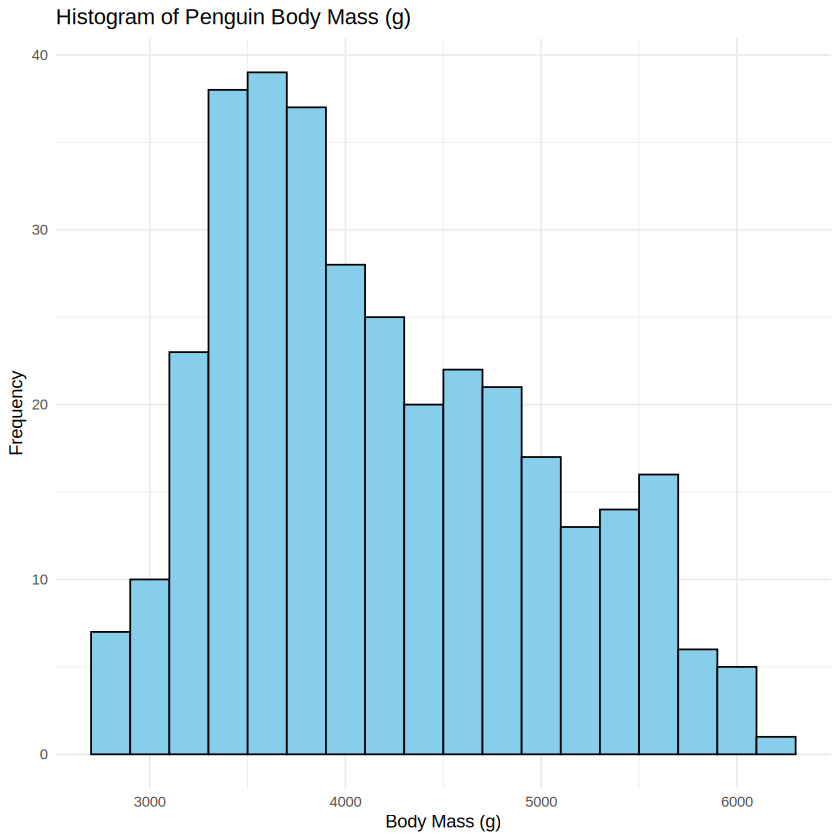

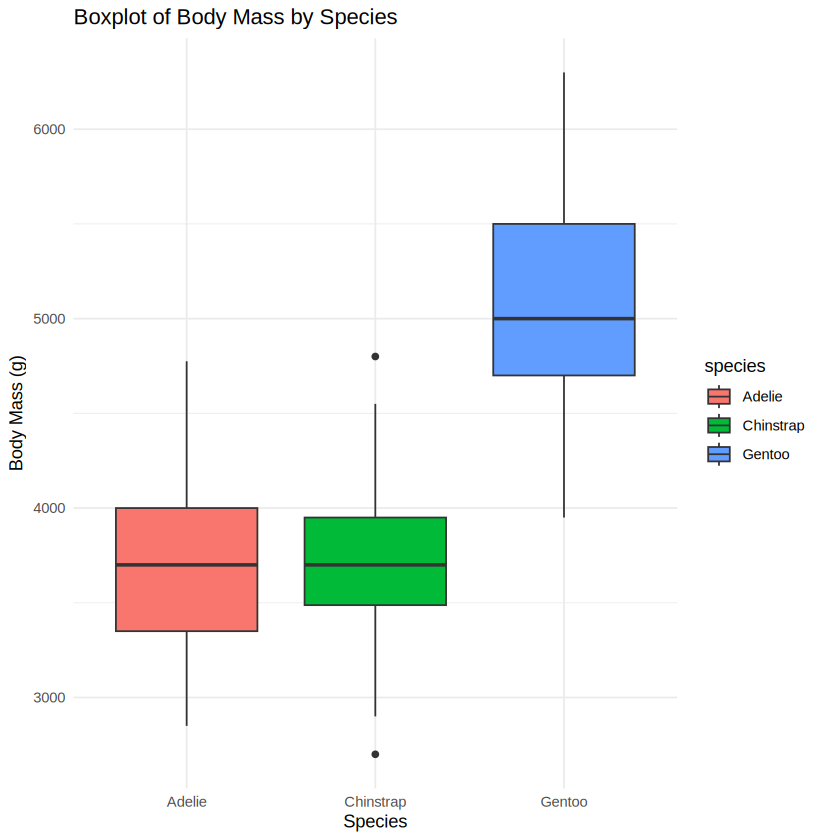

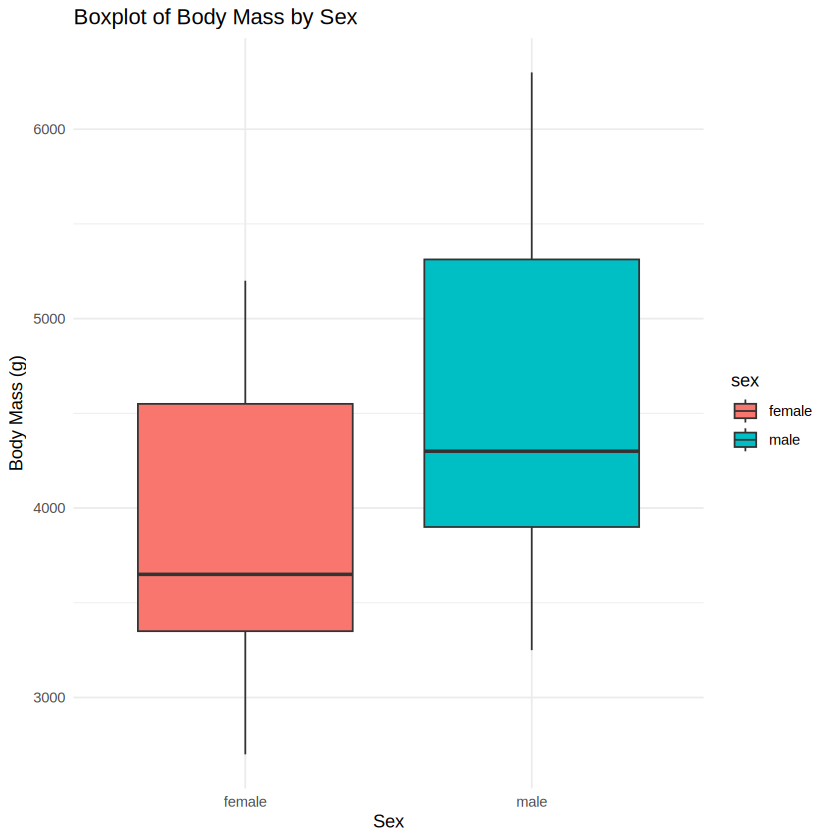

In [22]:
# Histogram of Body Mass
ggplot(penguins_clean, aes(x = body_mass_g)) +
  geom_histogram(binwidth = 200, fill = "skyblue", color = "black") +
  labs(title = "Histogram of Penguin Body Mass (g)", x = "Body Mass (g)", y = "Frequency") +
  theme_minimal()

# Species-wise Boxplot of Body Mass
ggplot(penguins_clean, aes(x = species, y = body_mass_g, fill = species)) +
  geom_boxplot() +
  labs(title = "Boxplot of Body Mass by Species", x = "Species", y = "Body Mass (g)") +
  theme_minimal()

# Sex-wise Boxplot of Body Mass
ggplot(penguins_sex_clean, aes(x = sex, y = body_mass_g, fill = sex)) +
  geom_boxplot() +
  labs(title = "Boxplot of Body Mass by Sex", x = "Sex", y = "Body Mass (g)") +
  theme_minimal()

#### 7.2 Normality Check Visualizations (QQ-plots)

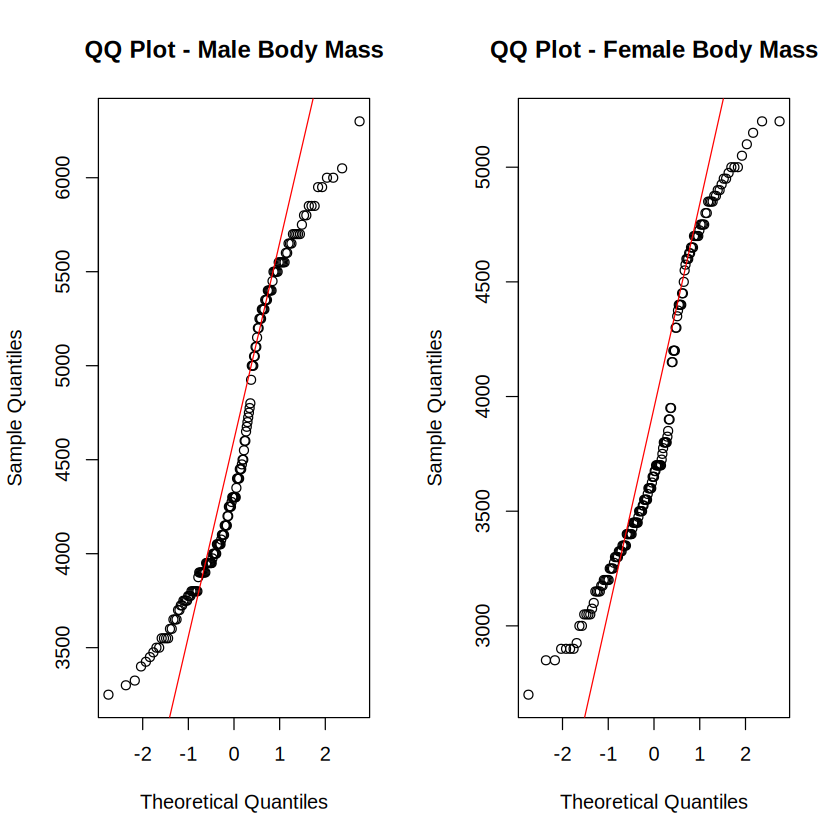

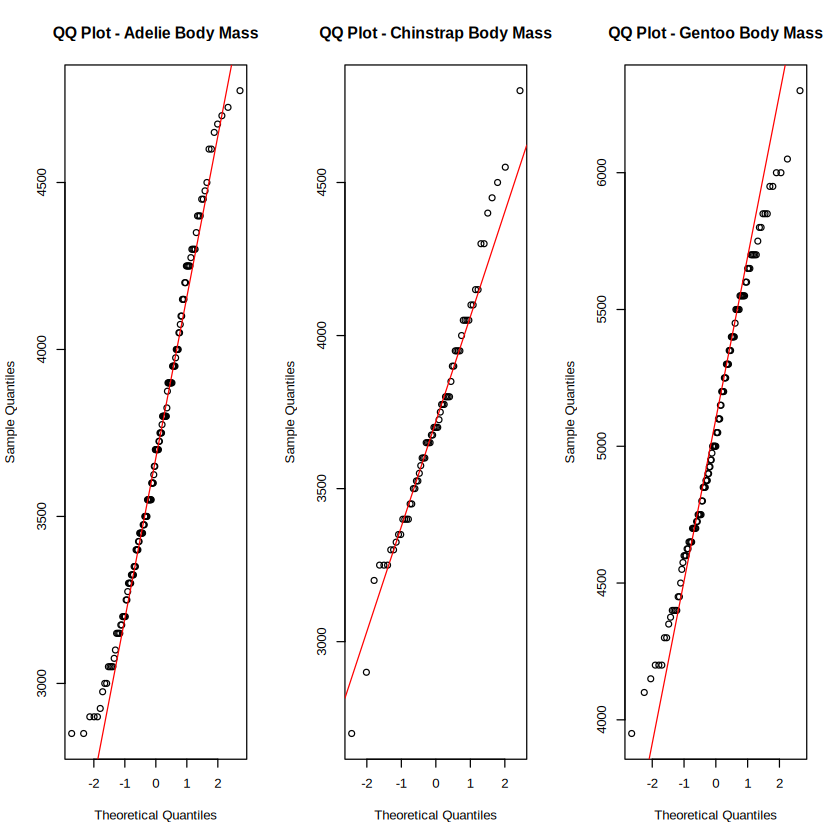

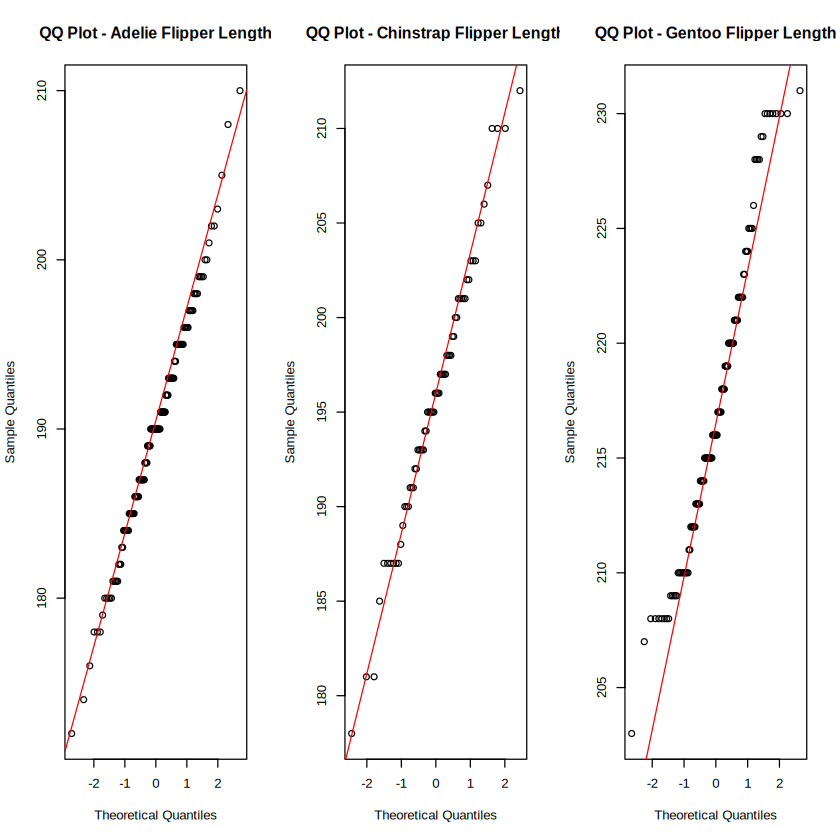

In [23]:
# QQ-plots for Body Mass by Sex
par(mfrow = c(1, 2))
qqnorm(penguins_sex_clean %>% filter(sex == "male") %>% pull(body_mass_g), main = "QQ Plot - Male Body Mass")
qqline(penguins_sex_clean %>% filter(sex == "male") %>% pull(body_mass_g), col = "red")
qqnorm(penguins_sex_clean %>% filter(sex == "female") %>% pull(body_mass_g), main = "QQ Plot - Female Body Mass")
qqline(penguins_sex_clean %>% filter(sex == "female") %>% pull(body_mass_g), col = "red")
par(mfrow = c(1, 1))

# QQ-plots for Body Mass by Species
par(mfrow = c(1, 3))
qqnorm(penguins_clean %>% filter(species == "Adelie") %>% pull(body_mass_g), main = "QQ Plot - Adelie Body Mass")
qqline(penguins_clean %>% filter(species == "Adelie") %>% pull(body_mass_g), col = "red")
qqnorm(penguins_clean %>% filter(species == "Chinstrap") %>% pull(body_mass_g), main = "QQ Plot - Chinstrap Body Mass")
qqline(penguins_clean %>% filter(species == "Chinstrap") %>% pull(body_mass_g), col = "red")
qqnorm(penguins_clean %>% filter(species == "Gentoo") %>% pull(body_mass_g), main = "QQ Plot - Gentoo Body Mass")
qqline(penguins_clean %>% filter(species == "Gentoo") %>% pull(body_mass_g), col = "red")
par(mfrow = c(1, 1))

# QQ-plots for Flipper Length by Species
par(mfrow = c(1, 3))
qqnorm(penguins_flipper_clean %>% filter(species == "Adelie") %>% pull(flipper_length_mm), main = "QQ Plot - Adelie Flipper Length")
qqline(penguins_flipper_clean %>% filter(species == "Adelie") %>% pull(flipper_length_mm), col = "red")
qqnorm(penguins_flipper_clean %>% filter(species == "Chinstrap") %>% pull(flipper_length_mm), main = "QQ Plot - Chinstrap Flipper Length")
qqline(penguins_flipper_clean %>% filter(species == "Chinstrap") %>% pull(flipper_length_mm), col = "red")
qqnorm(penguins_flipper_clean %>% filter(species == "Gentoo") %>% pull(flipper_length_mm), main = "QQ Plot - Gentoo Flipper Length")
qqline(penguins_flipper_clean %>% filter(species == "Gentoo") %>% pull(flipper_length_mm), col = "red")
par(mfrow = c(1, 1))

#### 7.3 Flipper Length Visualizations and Group Comparisons

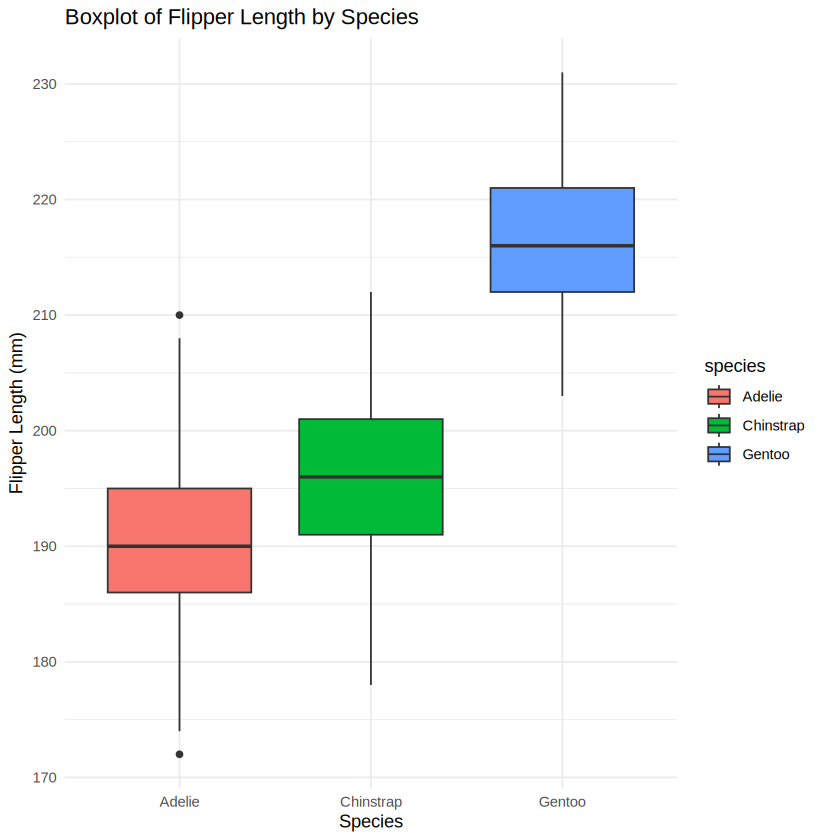

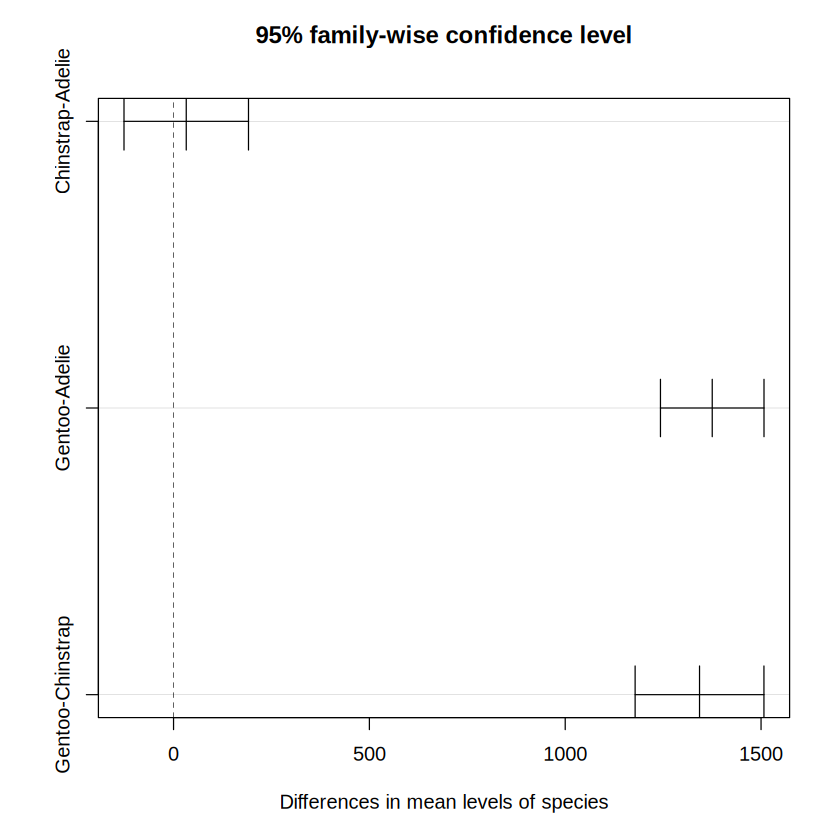

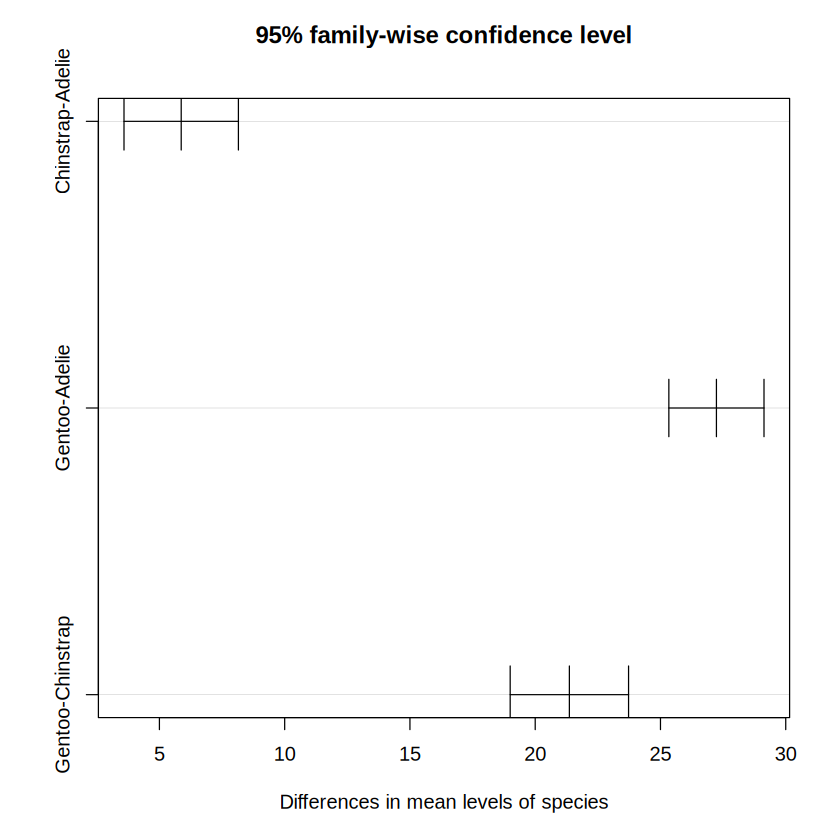

In [24]:
# Species-wise Flipper-Length Comparison (Boxplot)
ggplot(penguins_flipper_clean, aes(x = species, y = flipper_length_mm, fill = species)) +
  geom_boxplot() +
  labs(title = "Boxplot of Flipper Length by Species", x = "Species", y = "Flipper Length (mm)") +
  theme_minimal()

# Group comparison plot showing significant differences among species (Tukey HSD for Body Mass)
plot(tukey_hsd_result)

# Group comparison plot showing significant differences among species (Tukey HSD for Flipper Length)
plot(tukey_hsd_flipper_result)

### 8. Final Summary Table of Major Statistical Tests

In [25]:
# Create the summary table
summary_data <- data.frame(
  Analysis = c(
    "Male vs Female Body Mass",
    "Body Mass Across Species (ANOVA)",
    "Kruskal-Wallis Test",
    "Two-Way ANOVA: Species",
    "Two-Way ANOVA: Sex",
    "Two-Way ANOVA: Interaction",
    "Flipper Length Across Species (ANOVA)"
  ),
  Test_Used = c(
    "Welch's t-test",
    "One-Way ANOVA",
    "Kruskal-Wallis Rank Sum Test",
    "Two-Way ANOVA",
    "Two-Way ANOVA",
    "Two-Way ANOVA",
    "One-Way ANOVA"
  ),
  Test_Statistic = c(
    paste0("t = ", round(t_test_result$statistic, 3)),
    paste0("F = ", round(summary(anova_result)[[1]]$`F value`[1], 3)),
    paste0("Chi-squared = ", round(kruskal_wallis_result$statistic, 3)),
    paste0("F = ", round(summary(two_way_anova_result)[[1]]$`F value`[1], 3)),
    paste0("F = ", round(summary(two_way_anova_result)[[1]]$`F value`[2], 3)),
    paste0("F = ", round(summary(two_way_anova_result)[[1]]$`F value`[3], 3)),
    paste0("F = ", round(summary(anova_flipper_result)[[1]]$`F value`[1], 3))
  ),
  p_value = c(
    format.pval(t_test_result$p.value, digits = 3),
    format.pval(summary(anova_result)[[1]]$`Pr(>F)`[1], digits = 3),
    format.pval(kruskal_wallis_result$p.value, digits = 3),
    format.pval(summary(two_way_anova_result)[[1]]$`Pr(>F)`[1], digits = 3),
    format.pval(summary(two_way_anova_result)[[1]]$`Pr(>F)`[2], digits = 3),
    format.pval(summary(two_way_anova_result)[[1]]$`Pr(>F)`[3], digits = 3),
    format.pval(summary(anova_flipper_result)[[1]]$`Pr(>F)`[1], digits = 3)
  ),
  Decision = c(
    ifelse(t_test_result$p.value < 0.05, "Reject H0", "Fail to Reject H0"),
    ifelse(summary(anova_result)[[1]]$`Pr(>F)`[1] < 0.05, "Reject H0", "Fail to Reject H0"),
    ifelse(kruskal_wallis_result$p.value < 0.05, "Reject H0", "Fail to Reject H0"),
    ifelse(summary(two_way_anova_result)[[1]]$`Pr(>F)`[1] < 0.05, "Reject H0", "Fail to Reject H0"),
    ifelse(summary(two_way_anova_result)[[1]]$`Pr(>F)`[2] < 0.05, "Reject H0", "Fail to Reject H0"),
    ifelse(summary(two_way_anova_result)[[1]]$`Pr(>F)`[3] < 0.05, "Reject H0", "Fail to Reject H0"),
    ifelse(summary(anova_flipper_result)[[1]]$`Pr(>F)`[1] < 0.05, "Reject H0", "Fail to Reject H0")
  ),
  Conclusion = c(
    "Significant difference in mean body mass between sexes",
    "Significant difference in mean body mass among species",
    "Significant difference in median body mass among species",
    "Significant main effect of species on body mass",
    "Significant main effect of sex on body mass",
    "Significant interaction effect between species and sex",
    "Significant difference in mean flipper length among species"
  )
)

print(summary_data)

                               Analysis                    Test_Used
1              Male vs Female Body Mass               Welch's t-test
2      Body Mass Across Species (ANOVA)                One-Way ANOVA
3                   Kruskal-Wallis Test Kruskal-Wallis Rank Sum Test
4                Two-Way ANOVA: Species                Two-Way ANOVA
5                    Two-Way ANOVA: Sex                Two-Way ANOVA
6            Two-Way ANOVA: Interaction                Two-Way ANOVA
7 Flipper Length Across Species (ANOVA)                One-Way ANOVA
         Test_Statistic  p_value  Decision
1            t = -8.555 4.79e-16 Reject H0
2           F = 343.626   <2e-16 Reject H0
3 Chi-squared = 217.599   <2e-16 Reject H0
4           F = 758.358   <2e-16 Reject H0
5            F = 387.46   <2e-16 Reject H0
6             F = 8.757 0.000197 Reject H0
7           F = 594.802   <2e-16 Reject H0
                                                   Conclusion
1      Significant difference in mean body

## 9. Final Conclusion

This comprehensive statistical analysis of the Palmer Penguins dataset revealed several important insights into the physical characteristics of the three penguin species—Adelie, Chinstrap, and Gentoo—and the differences between male and female penguins. The analysis focused primarily on **body mass** and **flipper length** using descriptive statistics, hypothesis testing, ANOVA, non-parametric tests, and visualizations.

### Main Descriptive Findings

**Body Mass:**
Gentoo penguins displayed the highest mean body mass among the three species. Chinstrap and Adelie penguins had relatively similar average body masses. The distribution of body mass varied across species, with Gentoo penguins generally showing larger body mass values.

**Flipper Length:**
Similar to body mass, Gentoo penguins exhibited the longest average flipper lengths, followed by Chinstrap and Adelie penguins.

### Male vs. Female Body Mass

An independent **Welch's two-sample t-test** demonstrated a statistically significant difference in mean body mass between male and female penguins. The 95% confidence interval for the difference in mean body mass did not include zero, further supporting the presence of a significant difference between the two groups.

The calculated **Cohen's d** indicated a large effect size, suggesting that the difference in body mass between male and female penguins is not only statistically significant but also practically meaningful. Overall, male penguins were generally heavier than female penguins.

### Species Differences in Body Mass

A **One-Way ANOVA** was performed to determine whether mean body mass differed among Adelie, Chinstrap, and Gentoo penguins. The results indicated a statistically significant difference in mean body mass among the three species.

The **Tukey's HSD post-hoc test** further clarified these differences. Gentoo penguins were significantly heavier than both Adelie and Chinstrap penguins. However, there was no statistically significant difference in mean body mass between Adelie and Chinstrap penguins.

### Comparison of ANOVA and Kruskal-Wallis Test

Although some ANOVA assumptions showed possible violations, the non-parametric **Kruskal-Wallis test** produced results consistent with the One-Way ANOVA. Both tests indicated significant differences in body mass among the penguin species.

This agreement between the parametric and non-parametric approaches strengthens the reliability and robustness of the conclusion that penguin species differ significantly in their body mass.

### Effects of Species and Sex: Two-Way ANOVA

The **Two-Way ANOVA** examined the effects of both species and sex on penguin body mass.

The analysis showed significant main effects of **species** and **sex**, indicating that both factors have an important influence on body mass. The interaction between species and sex was also significant, suggesting that the difference in body mass between males and females is not identical across all species.

In other words, the effect of sex on body mass depends to some extent on the particular penguin species.

### Flipper Length Findings

A **One-Way ANOVA** for flipper length revealed statistically significant differences among the three penguin species.

The **Tukey's HSD post-hoc test** showed significant differences for all three pairwise comparisons:

* Adelie vs. Chinstrap
* Adelie vs. Gentoo
* Chinstrap vs. Gentoo

Gentoo penguins had the longest flippers, followed by Chinstrap and Adelie penguins. This differs slightly from the body mass analysis, where Adelie and Chinstrap penguins did not show a statistically significant difference in mean body mass.

### Overall Conclusion

The Palmer Penguins dataset clearly demonstrates significant physical differences among the Adelie, Chinstrap, and Gentoo penguin species. **Gentoo penguins were consistently larger, exhibiting both higher body mass and longer flippers compared with the other species.**

Sex also played a significant role in body mass, with male penguins generally being heavier than female penguins. Furthermore, the Two-Way ANOVA indicated that the relationship between sex and body mass varies across different species.

Overall, this experiment successfully demonstrated the application of **descriptive statistics, Welch's t-test, Cohen's d effect size, One-Way ANOVA, Tukey's HSD post-hoc analysis, Kruskal-Wallis test, Two-Way ANOVA, and graphical visualization techniques**.

The findings highlight the importance of using both **parametric and non-parametric statistical methods** to obtain reliable conclusions when analyzing biological and ecological data. The analysis confirms that both **species and sex are important factors influencing the physical characteristics of Palmer penguins**.
